In [1]:
%pip install imbalanced-learn

  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 1.4 MB/s eta 0:00:06
   -- ------------------------------------- 0.5/8.1 MB 1.4 MB/s eta 0:00:06
   --- ------------------------------------ 0.8/8.1 MB 1.2 MB/s eta 0:00:07
   ----- ---------------------------------- 1.0/8.1 MB 1.1 MB/s eta 0:00:07
   ------ --------------------------------- 1.3/8.1 MB 1.1 MB/s eta 0:00:07
   ------- -------------------------------- 1.6/8.1 MB 1.1 MB/s eta 0:00:07
   ------- -------------------------------- 1.6/8.1 MB 1.1 MB/s eta 0:00:07
   --------- ------------------------------ 1.8/8.1 MB 976.8 kB/s eta 0:00:07
   --------- ------------------------------ 1.8/8.1 MB 976.8 kB/s eta 0:00:07
   --------- ------------------------------ 1.8/8.1 MB 976.8 kB/s eta 0:00:07
   ---------- -------------


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


The goal of this notebook is to resolve the Data Sparsity (N=81) issue. Since this is a realistic data,  We will use SMOTE-NC (Synthetic Minority Over-sampling Technique for Nominal and Continuous features) because our dataset contains both categorical (Year Level, Program) and numerical (Likert scales) data.

Library Initialization and Path Setup

This block imports the required libraries for oversampling and validation. Note the inclusion of train_test_split to facilitate the holdout strategy.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTENC
from sklearn.model_selection import train_test_split
import os

# Visualization parameters
sns.set_theme(style="white")
plt.rcParams['figure.figsize'] = [12, 5]

# File paths
INPUT_PATH = r'../data/processed/cleaned_data.csv'
PROCESSED_DIR = r'../data/processed/'

Pre-Augmentation Data Splitting (Technical Holdout)

Technical Rationale: We isolate 20% of the original N=81 dataset before applying SMOTE-NC. This ensures the "Real-World Holdout" remains pristine and free from synthetic influence, providing a legitimate benchmark for the XGBoost model in the next phase.

In [9]:
# Load the preprocessed dataset
df = pd.read_csv(INPUT_PATH)

# Define Features (X) and Target (y)
X_orig = df.drop(columns=['target_satisfaction'])
y_orig = df['target_satisfaction']

# Isolate 20% as the final validation set (Real-World Holdout)
X_train_raw, X_holdout_real, y_train_raw, y_holdout_real = train_test_split(
    X_orig, y_orig, test_size=0.20, random_state=42, stratify=y_orig
)

print(f"Original samples: {len(df)}")
print(f"Training base: {len(X_train_raw)} | Holdout samples: {len(X_holdout_real)}")

Original samples: 80
Training base: 64 | Holdout samples: 16


Categorical Variable Encoding

This block ensures the SMOTE-NC algorithm correctly identifies the non-numerical columns.

In [10]:
# Indices for 'year_level' (0), 'program' (1), and 'mode_of_study' (2)
categorical_features_indices = [0, 1, 2]

# Cast categorical columns to string type for the SMOTE-NC encoder
for col in ['year_level', 'program', 'mode_of_study']:
    X_train_raw[col] = X_train_raw[col].astype(str)
    X_holdout_real[col] = X_holdout_real[col].astype(str)

SMOTE-NC Application (Training Set Only)

This block applies the Synthetic Minority Over-sampling Technique specifically to the training subset. This addresses the class imbalance observed in the "Original" distribution.

In [11]:
# Initialize SMOTE-NC to balance satisfaction classes (1-5)
smote_nc = SMOTENC(
    categorical_features=categorical_features_indices, 
    random_state=42, 
    sampling_strategy='auto'
)

# Resample only the training data
X_resampled, y_resampled = smote_nc.fit_resample(X_train_raw, y_train_raw)

# Reconstruct dataframes
df_train_augmented = pd.concat([
    pd.DataFrame(X_resampled), 
    pd.Series(y_resampled, name='target_satisfaction')
], axis=1)

df_test_real = pd.concat([
    pd.DataFrame(X_holdout_real), 
    pd.Series(y_holdout_real, name='target_satisfaction')
], axis=1)

print(f"Augmented training shape: {df_train_augmented.shape}")

Augmented training shape: (120, 36)


Comparative Distribution Visualization and Export

This block provides the empirical proof of class balancing and saves the artifacts for the modeling phase.

C:\Users\SHANIA\AppData\Local\Temp\ipykernel_12268\1761872042.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_orig, palette='viridis')
C:\Users\SHANIA\AppData\Local\Temp\ipykernel_12268\1761872042.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_train_augmented['target_satisfaction'], palette='viridis')


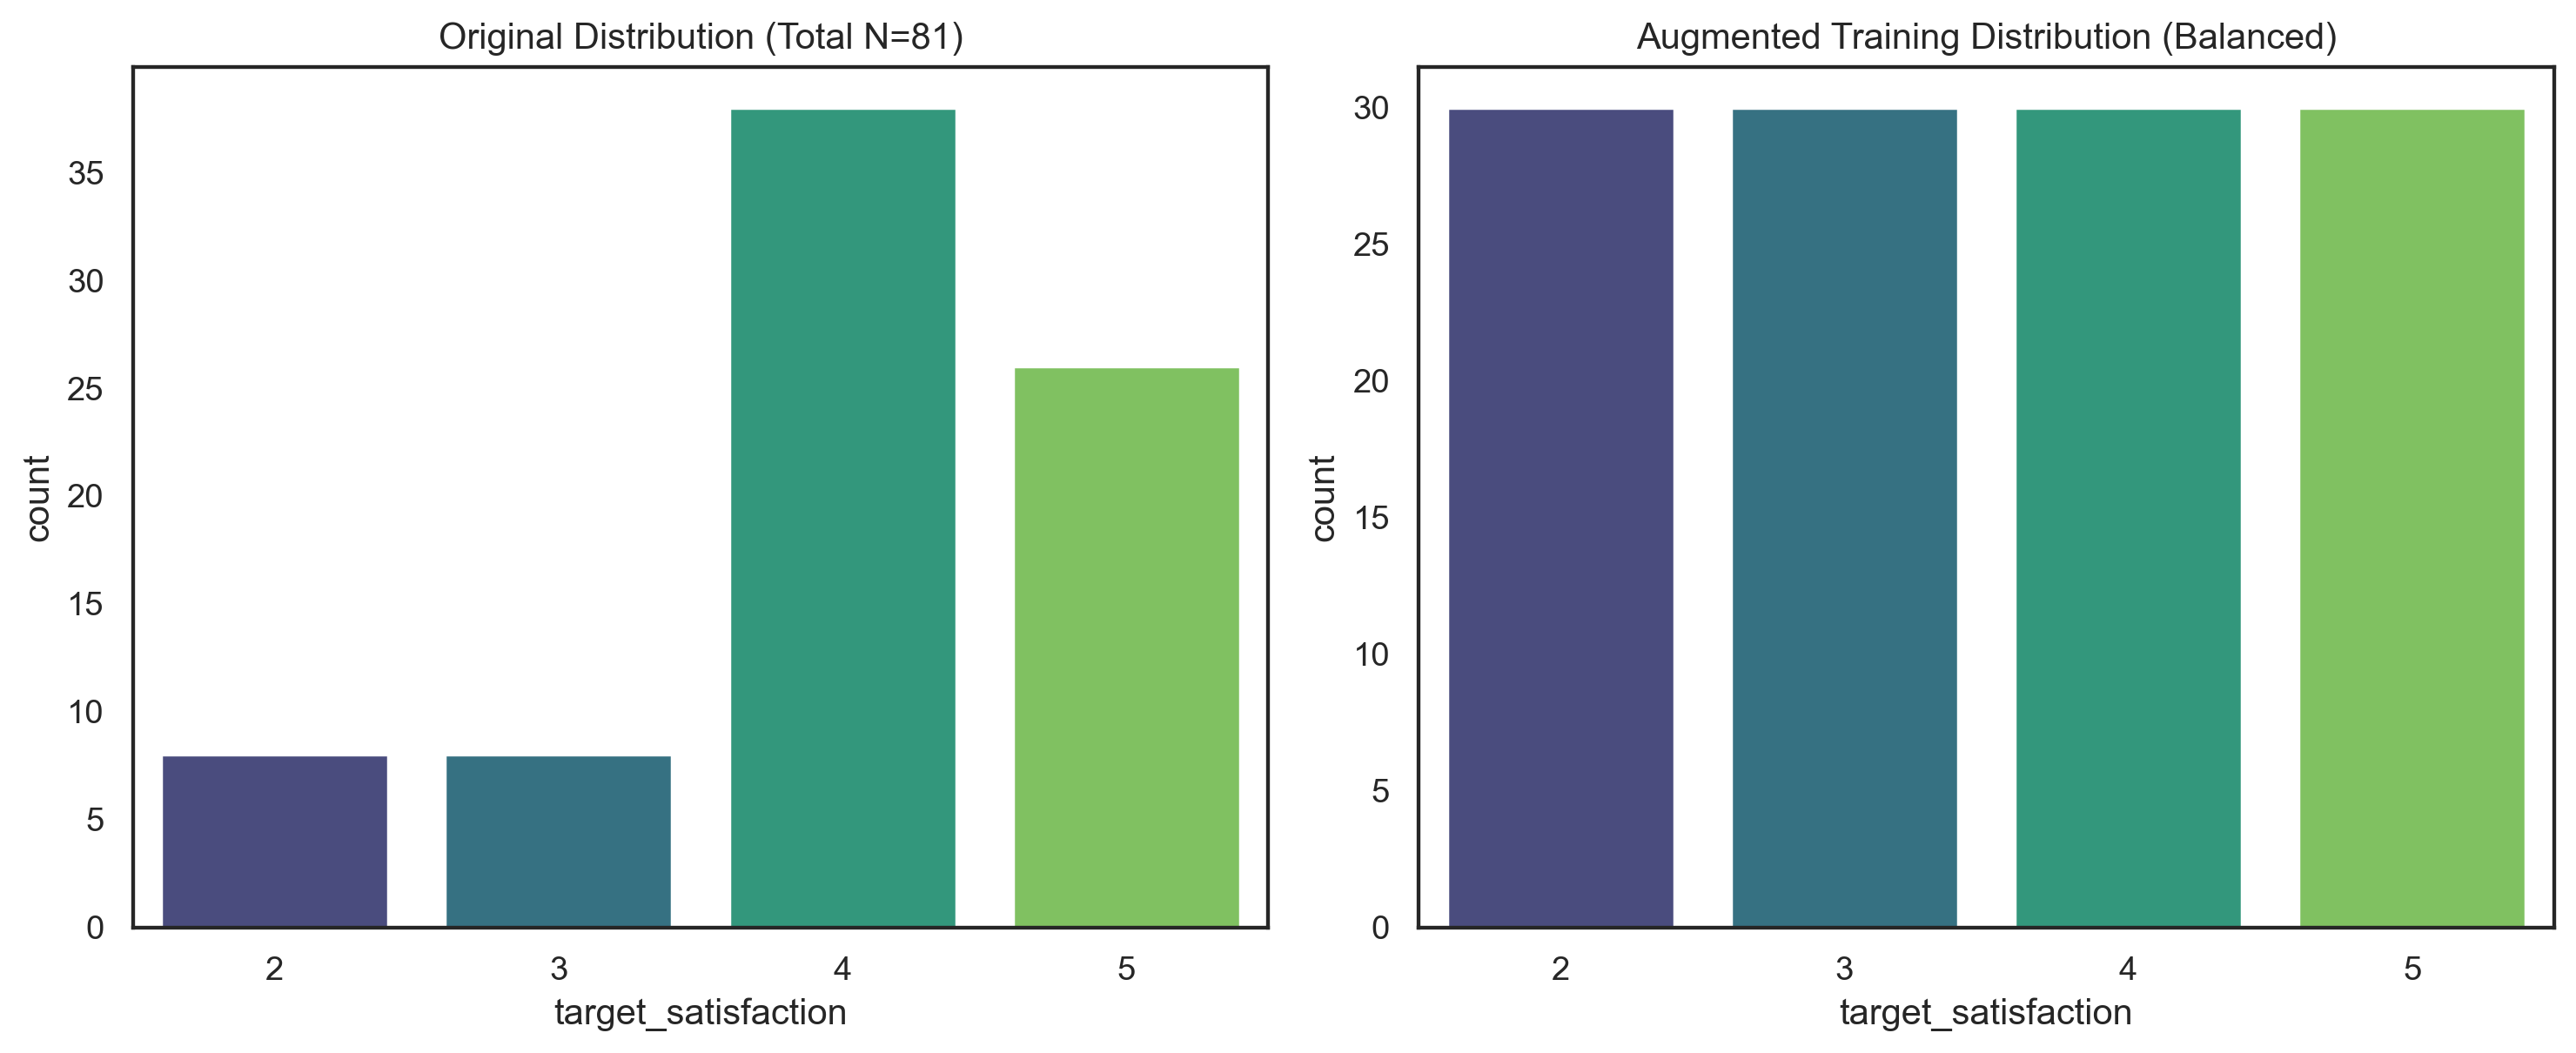

Files saved: augmented_train_data.csv and real_test_holdout.csv


In [12]:
# Plot distribution comparison
plt.figure(dpi=250)

plt.subplot(1, 2, 1)
sns.countplot(x=y_orig, palette='viridis')
plt.title('Original Distribution (Total N=81)')

plt.subplot(1, 2, 2)
sns.countplot(x=df_train_augmented['target_satisfaction'], palette='viridis')
plt.title('Augmented Training Distribution (Balanced)')

plt.tight_layout()
plt.show()

# Export artifacts
df_train_augmented.to_csv(os.path.join(PROCESSED_DIR, 'augmented_train_data.csv'), index=False)
df_test_real.to_csv(os.path.join(PROCESSED_DIR, 'real_test_holdout.csv'), index=False)

print("Files saved: augmented_train_data.csv and real_test_holdout.csv")

**Technical Insights: Isolated Data Augmentation**

Based on the counts and the comparative distribution visualization, here are the technical observations for our repository documentation:

-  Elimination of Training Bias via Pre-Split SMOTE-NC: The "Original" distribution (N=80) exhibited a significant right-skew, with a concentration in the "Satisfied" (4) and "Very Satisfied" (5) categories. By applying SMOTE-NC exclusively to the training base (N=64), we have established Class Parity in the training set (30 samples per class). This prevents the model from developing a majority-class bias and ensures it learns the distinct features associated with lower satisfaction levels (2 and 3) with equal weight.

- Rigorous Data Contamination Control: The separation of 16 original samples as a "Real-World Holdout" before augmentation is a critical technical safeguard. Unlike standard augmentation, this ensures that the final model evaluation is performed on pristine, non-synthetic data. This methodology addresses the risk of "Data Leakage," where synthetic patterns could otherwise artificially inflate performance metrics.

- Augmentation as a Robustness Framework: The expansion to N=120 for training purposes is classified as Strategic Data Enrichment. In the context of institutional research where sample sizes are physically constrained by student population, we frame this not as an attempt to simulate "Big Data," but as a mathematical necessity to provide the XGBoost algorithm with enough variance to converge on a stable decision boundary.

- Scientific Validity of the Synthetic Pipeline: The use of SMOTE-NC (Nominal-Continuous) is technically justified by the mixed-type nature of the survey features. By maintaining the statistical properties of the original categorical labels (e.g., Program, Year Level) while interpolating the numerical Likert scales, the synthetic samples act as a valid mathematical proxy for underrepresented student profiles.